In [2]:
%load_ext autoreload
%autoreload 2

import glob, h5py, math, time, os, json
from scipy.stats import norm, expon, chi2, uniform, chisquare, gamma
import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager

import sys  
sys.path.insert(1, '../utils/')
import new_nplm as nplm
from ANALYSISutils import plot_2distribution

from scipy.stats import norm

sys.path.append("../../")
from utils.nplm_postproc import extract_tstat, get_statistics, get_statistics_npy
from utils import plotting

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
# hyper parameters of the NPLM model
flk_sigmas = [0.1, 1.5, 2.6, 3.6, 4.9, 9.8] # values of kernel's width used for multiple testing

# files containing the toys for different physics assumptions
# keep 'ref' as key for the calibraiton toys for consistence
base_dir = "/n/home11/sambt/phlab-neurips25/nplm/experiments_output/jetclass_T0.1_v2/M244_lam1e-07_iter10000000_sigma0.1-1.5-2.6-3.6-4.9-9.8-_NoPois/"
files_dict = {
    'ref': f"{base_dir}/Nref50000_Nbkg10000/tests_all.h5",
    0.001: f"{base_dir}/Nref50000_Nbkg10000_Nsig10/tests_all.h5",
    0.002: f"{base_dir}/Nref50000_Nbkg10000_Nsig20/tests_all.h5",
    0.005: f"{base_dir}/Nref50000_Nbkg10000_Nsig50/tests_all.h5",
    0.01: f"{base_dir}/Nref50000_Nbkg10000_Nsig100/tests_all.h5",
    0.02: f"{base_dir}/Nref50000_Nbkg10000_Nsig200/tests_all.h5",
    0.05: f"{base_dir}/Nref50000_Nbkg10000_Nsig500/tests_all.h5",
}
# key values extraction
files = list(files_dict.values())
labels_list = list(files_dict.keys())
inj_fractions = sorted([k for k in files_dict.keys() if k != 'ref'])

NTOYS = 500
tstats_nplm = extract_tstat(files_dict, flk_sigmas, NTOYS=NTOYS)
statistics_nplm = get_statistics(tstats_nplm, flk_sigmas)
inj_fractions = sorted([k for k in files_dict.keys() if k != 'ref'])

pvalues = statistics_nplm['pvalues']
pvalues_min = statistics_nplm['pvalues_min']
pvalues_avg = statistics_nplm['pvalues_avg']
pvalues_prod = statistics_nplm['pvalues_prod']
z_obs = statistics_nplm['z_obs']
z_obs_p = statistics_nplm['z_obs_p']
z_obs_m = statistics_nplm['z_obs_m']
z_emp = statistics_nplm['z_emp']
z_emp_p = statistics_nplm['z_emp_p']
z_emp_m = statistics_nplm['z_emp_m']
z_min = statistics_nplm['z_min']
z_avg = statistics_nplm['z_avg']
z_prod = statistics_nplm['z_prod']

ideal_zscores = np.load("/n/home11/sambt/phlab-neurips25/experiments/jetclass/jetClass_T0.1_idealZscores_LRtestWithFit_nbkg10k.npz")
double_ideal_zscores = np.load("/n/home11/sambt/phlab-neurips25/experiments/jetclass/jetClassWithHbb_T0.1_idealZscores_LRtestWithFit_nbkg10k.npz")
maha_emp_zscores = np.load("/n/home11/sambt/phlab-neurips25/nplm/notebooks_maha/jetclass_maha_empiricalZscore.npz")

# FID scores
fid_path = "/n/home11/sambt/phlab-neurips25/nplm/experiments_output/jetclass_T0.1_v2/FID_NoPois/"
files_dict_fid = {
    'ref': fid_path + "Nref50000_Nbkg10000_Nsig0/test_all.npy",
    0.001: fid_path + "Nref50000_Nbkg10000_Nsig10/test_all.npy",
    0.002: fid_path + "Nref50000_Nbkg10000_Nsig20/test_all.npy",
    0.005: fid_path + "Nref50000_Nbkg10000_Nsig50/test_all.npy",
    0.01: fid_path + "Nref50000_Nbkg10000_Nsig100/test_all.npy",
    0.02: fid_path + "Nref50000_Nbkg10000_Nsig200/test_all.npy",
    0.05: fid_path + "Nref50000_Nbkg10000_Nsig500/test_all.npy"
}
tstats_fid = extract_tstat(files_dict_fid, flk_sigmas, NTOYS=NTOYS, ftype='npy')
statistics_fid = get_statistics_npy(tstats_fid)
inj_fractions_fid = sorted([k for k in files_dict_fid.keys() if k != 'ref'])

# MMD scores
mmd_path = "/n/home11/sambt/phlab-neurips25/nplm/experiments_output/jetclass_T0.1_v2/NysMMD_M244_NoPois/"
files_dict_mmd = {
    'ref': mmd_path + "Nref50000_Nbkg10000_Nsig0/test_all.npy",
    0.001: mmd_path + "Nref50000_Nbkg10000_Nsig10/test_all.npy",
    0.002: mmd_path + "Nref50000_Nbkg10000_Nsig20/test_all.npy",
    0.005: mmd_path + "Nref50000_Nbkg10000_Nsig50/test_all.npy",
    0.01: mmd_path + "Nref50000_Nbkg10000_Nsig100/test_all.npy",
    0.02: mmd_path + "Nref50000_Nbkg10000_Nsig200/test_all.npy",
    0.05: mmd_path + "Nref50000_Nbkg10000_Nsig500/test_all.npy"
}
tstats_mmd = extract_tstat(files_dict_mmd, flk_sigmas, NTOYS=NTOYS, ftype='npy')
statistics_mmd = get_statistics_npy(tstats_mmd)
inj_fractions_mmd = sorted([k for k in files_dict_mmd.keys() if k != 'ref'])

# plot Z scores

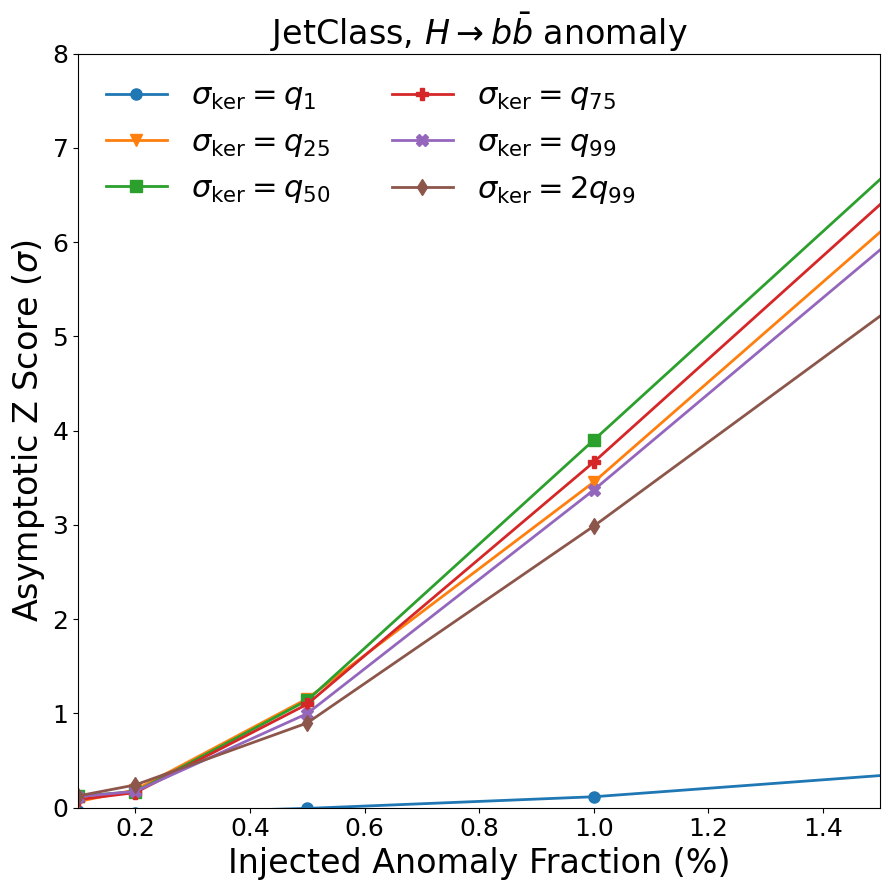

In [4]:
plt.figure(figsize=(9,9))
plt.title(r"JetClass, $H\to b\bar{b}$ anomaly",fontsize=24)
x_values = [100*f for f in inj_fractions]
markers = ['o','v','s','P','X','d']
for isigma,sigma in enumerate(flk_sigmas):
    y_values = [z_obs[f][:,isigma] for f in inj_fractions]
    plt.plot(x_values,y_values,lw=2,
             marker=markers[isigma],markersize=8,
             color=f"C{isigma}",
             #label=f"$\sigma_\\text{{ker}} = {sigma:.1f}$")
             label=plotting.kernel_to_label[sigma])
#plt.xscale('log')
xlim = plt.gca().get_xlim()
#plt.plot(100*ideal_zscores['fracs'],ideal_zscores['zscores'],lw=2,linestyle='--',color='blue',label='Supervised')
#plt.plot(100*double_ideal_zscores['fracs'],double_ideal_zscores['zscores'],lw=2,linestyle='--',color='crimson',label='Ideal Supervised')
plt.xlim(xlim)
plt.xlim([0.1,1.5])
plt.ylim([0,8])
plt.yticks(fontsize=18)
plt.xticks(fontsize=18)
plt.ylabel("Asymptotic Z Score ($\sigma$)",fontsize=24)
plt.xlabel("Injected Anomaly Fraction (%)",fontsize=24)
plt.legend(ncol=2,fontsize=22,frameon=False)
plt.tight_layout()
plt.savefig("jetclass_plots/jetclass_Hbb_asymptoticZscores.pdf",bbox_inches='tight')

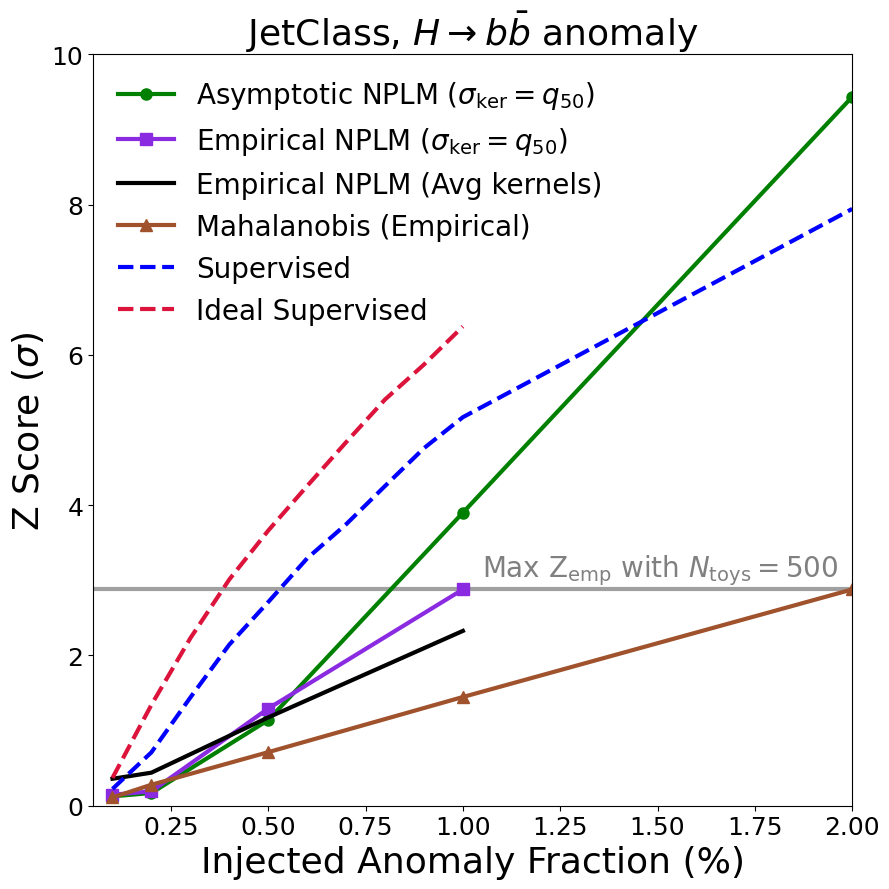

In [5]:
plt.figure(figsize=(9,9))
plt.title(r"JetClass, $H\to b\bar{b}$ anomaly",fontsize=26)
x_values = [100*f for f in inj_fractions]

best_sigma = 2.6
isigma = flk_sigmas.index(best_sigma)
handles_1=[]
sigma_label = plotting.kernel_to_label[best_sigma]

# asymptotic
y_values = [z_obs[f][:,isigma] for f in inj_fractions]
l1,=plt.plot(x_values,y_values,lw=3,
         marker='o',markersize=8,color='green',
         #label=f"Asymptotic NPLM ($\sigma_\\text{{ker}} = {best_sigma:.1f}$)")
         label=f"Asymptotic NPLM ({sigma_label})")
handles_1.append(l1)

#empirical
y_values = [z_emp[f][:,isigma] for f in inj_fractions]
l2,=plt.plot(x_values[:-2],y_values[:-2],lw=3,
         marker='s',markersize=8,color='blueviolet',
         #label=f"Empirical NPLM ($\sigma_\\text{{ker}} = {best_sigma:.1f}$)")
         label=f"Empirical NPLM ({sigma_label})")
handles_1.append(l2)

# empirical average
l3,=plt.plot(x_values[:-2],[z_avg[f] for f in inj_fractions][:-2],lw=3, linestyle='-',
         marker=None,color="k",label=f"Empirical NPLM (Avg kernels)")
handles_1.append(l3)

# maha
l7, = plt.plot(100*maha_emp_zscores['fracs'],maha_emp_zscores['zscores'],lw=3,color='sienna',label="Mahalanobis (Empirical)",
              marker='^',markersize=8)
handles_1.append(l7)

xlim = plt.gca().get_xlim()
l4,=plt.plot(100*ideal_zscores['fracs'],ideal_zscores['zscores'],
         lw=3,linestyle='--',color='blue',label='Supervised')
handles_1.append(l4)
l5,=plt.plot(100*double_ideal_zscores['fracs'],double_ideal_zscores['zscores'],
         lw=3,linestyle='--',color='crimson',label='Ideal Supervised')
handles_1.append(l5)

l6= plt.axhline(norm.ppf(1-1./NTOYS),lw=3,linestyle='-',color='gray',zorder=0,label=f"Max Z with $N_\\text{{toys}} = 500$",alpha=0.75)
handles_2 = [l6]

plt.xlim(xlim)
plt.xlim([0.05,2])
plt.ylim([0,10])
plt.yticks(fontsize=18)
plt.xticks(fontsize=18)
plt.ylabel("Z Score ($\sigma$)",fontsize=26)
plt.xlabel("Injected Anomaly Fraction (%)",fontsize=26)
#plt.grid(axis='y')
leg1 = plt.legend(handles=handles_1,ncol=1,fontsize=20,frameon=False,loc='upper left')
#leg2 = plt.legend(handles=handles_2,ncol=1,fontsize=20,frameon=False,loc='lower right')
#plt.gca().add_artist(leg1)
plt.text(1.05,3.05,f"Max Z$_\\text{{emp}}$ with $N_\\text{{toys}} = 500$",fontsize=20,color='gray')
plt.tight_layout()
plt.savefig("jetclass_plots/jetclass_Hbb_Zsummary.pdf",bbox_inches='tight')

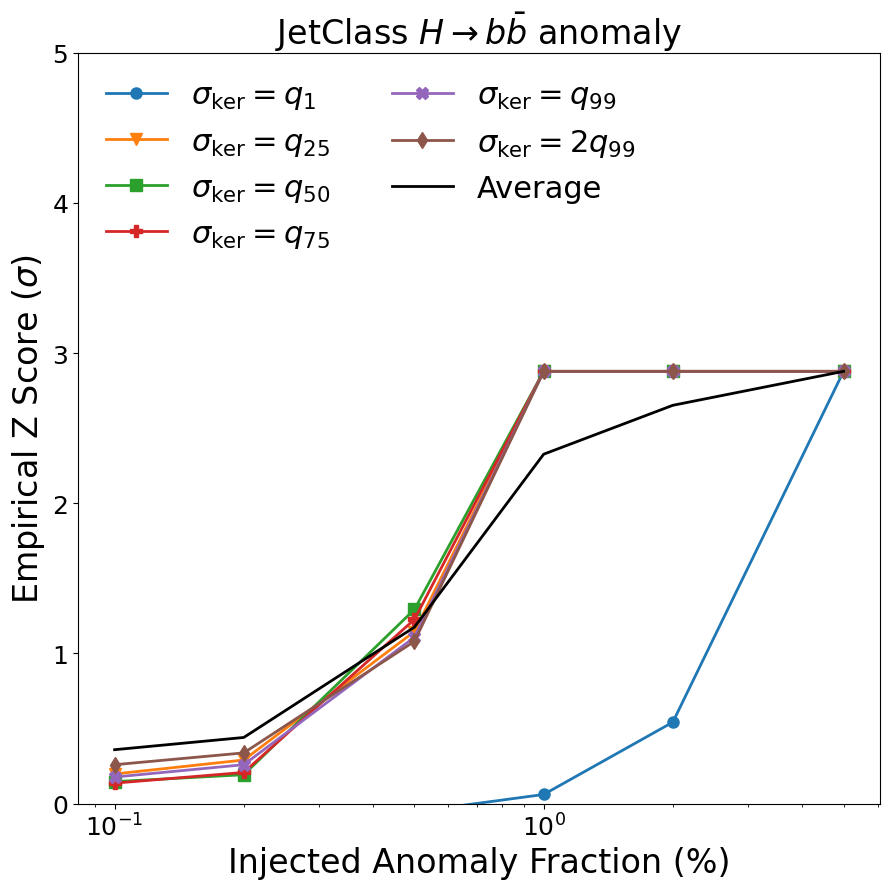

In [7]:
plt.figure(figsize=(9,9))
plt.title(r"JetClass $H\to b\bar{b}$ anomaly",fontsize=24)
x_values = [100*f for f in inj_fractions]
markers = ['o','v','s','P','X','d']
for isigma,sigma in enumerate(flk_sigmas):
    y_values = [z_emp[f][:,isigma] for f in inj_fractions]
    plt.plot(x_values,y_values,lw=2,
             marker=markers[isigma],markersize=8,
             color=f"C{isigma}",
             #label=f"$\sigma_\\text{{ker}} = {sigma:.1f}$")
             label=plotting.kernel_to_label[sigma])
#plt.plot(x_values,[z_min[f] for f in inj_fractions],lw=2, marker=None,color="k",label=f"Min Aggregation")
plt.plot(x_values,[z_avg[f] for f in inj_fractions],lw=2, linestyle='-',marker=None,color="k",label=f"Average")
#plt.plot(x_values,[z_prod[f] for f in inj_fractions],lw=2, linestyle='--',marker=None,color="k",label=f"Prod Aggregation")
plt.xscale('log')
plt.ylim([0,5])
plt.yticks(fontsize=18)
plt.xticks(fontsize=18)
plt.ylabel("Empirical Z Score ($\sigma$)",fontsize=24)
plt.xlabel("Injected Anomaly Fraction (%)",fontsize=24)
plt.legend(ncol=2,fontsize=22,frameon=False,loc='upper left')
plt.tight_layout()
plt.savefig("jetclass_plots/jetClass_Hbb_empiricalZ.pdf",bbox_inches='tight')

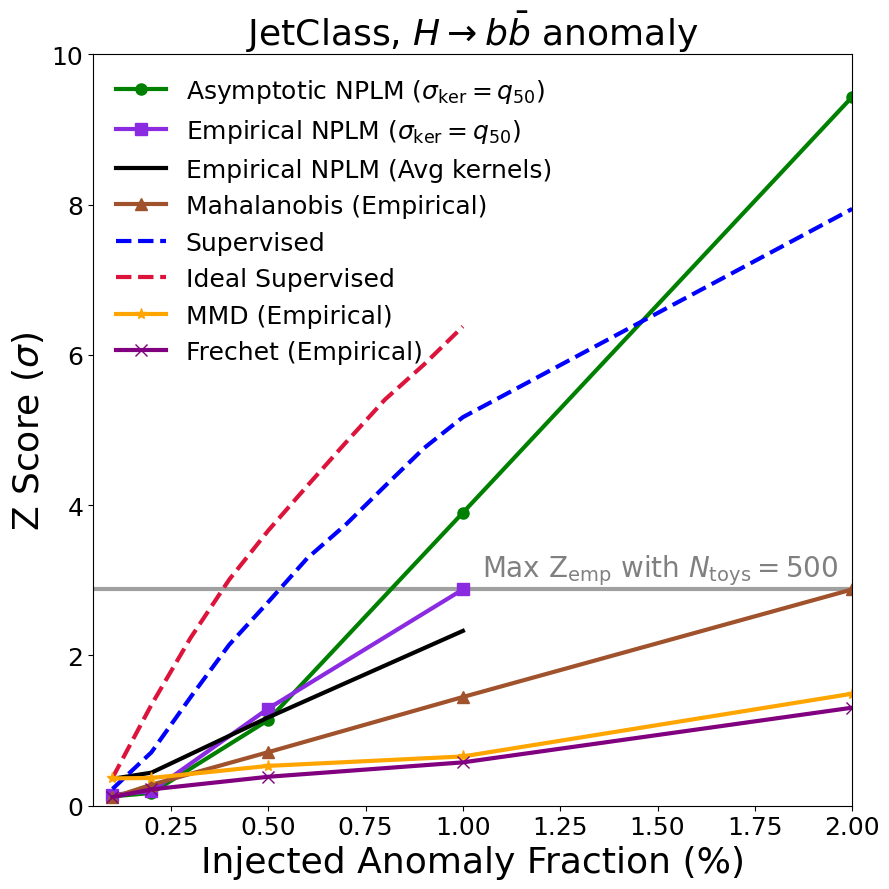

In [8]:
plt.figure(figsize=(9,9))
plt.title(r"JetClass, $H\to b\bar{b}$ anomaly",fontsize=26)
x_values = [100*f for f in inj_fractions]

best_sigma = 2.6
isigma = flk_sigmas.index(best_sigma)
handles_1=[]
sigma_label = plotting.kernel_to_label[best_sigma]

# asymptotic
y_values = [z_obs[f][:,isigma] for f in inj_fractions]
l1,=plt.plot(x_values,y_values,lw=3,
         marker='o',markersize=8,color='green',
         #label=f"Asymptotic NPLM ($\sigma_\\text{{ker}} = {best_sigma:.1f}$)")
         label=f"Asymptotic NPLM ({sigma_label})")
handles_1.append(l1)

#empirical
y_values = [z_emp[f][:,isigma] for f in inj_fractions]
l2,=plt.plot(x_values[:-2],y_values[:-2],lw=3,
         marker='s',markersize=8,color='blueviolet',
         #label=f"Empirical NPLM ($\sigma_\\text{{ker}} = {best_sigma:.1f}$)")
         label=f"Empirical NPLM ({sigma_label})")
handles_1.append(l2)

# empirical average
l3,=plt.plot(x_values[:-2],[z_avg[f] for f in inj_fractions][:-2],lw=3, linestyle='-',
         marker=None,color="k",label=f"Empirical NPLM (Avg kernels)")
handles_1.append(l3)

# maha
l7, = plt.plot(100*maha_emp_zscores['fracs'],maha_emp_zscores['zscores'],lw=3,color='sienna',label="Mahalanobis (Empirical)",
              marker='^',markersize=8)
handles_1.append(l7)

xlim = plt.gca().get_xlim()
l4,=plt.plot(100*ideal_zscores['fracs'],ideal_zscores['zscores'],
         lw=3,linestyle='--',color='blue',label='Supervised')
handles_1.append(l4)
l5,=plt.plot(100*double_ideal_zscores['fracs'],double_ideal_zscores['zscores'],
         lw=3,linestyle='--',color='crimson',label='Ideal Supervised')
handles_1.append(l5)

l6= plt.axhline(norm.ppf(1-1./NTOYS),lw=3,linestyle='-',color='gray',zorder=0,label=f"Max Z with $N_\\text{{toys}} = 500$",alpha=0.75)
handles_2 = [l6]

# mmd
y_values = [statistics_mmd['z_emp'][f] for f in inj_fractions_mmd]
l8, = plt.plot(100*np.array(inj_fractions_mmd),y_values,lw=3,color='orange',label="MMD (Empirical)",
              marker='*',markersize=8)
handles_1.append(l8)

# Frechet
y_values = [statistics_fid['z_emp'][f] for f in inj_fractions_fid]
l9, = plt.plot(100*np.array(inj_fractions_fid),y_values,lw=3,color='purple',label="Frechet (Empirical)",
              marker='x',markersize=8)
handles_1.append(l9)

plt.xlim(xlim)
plt.xlim([0.05,2])
plt.ylim([0,10])
plt.yticks(fontsize=18)
plt.xticks(fontsize=18)
plt.ylabel("Z Score ($\sigma$)",fontsize=26)
plt.xlabel("Injected Anomaly Fraction (%)",fontsize=26)
#plt.grid(axis='y')
leg1 = plt.legend(handles=handles_1,ncol=1,fontsize=18,frameon=False,loc='upper left')
#leg2 = plt.legend(handles=handles_2,ncol=1,fontsize=20,frameon=False,loc='lower right')
#plt.gca().add_artist(leg1)
plt.text(1.05,3.05,f"Max Z$_\\text{{emp}}$ with $N_\\text{{toys}} = 500$",fontsize=20,color='gray')
plt.tight_layout()
plt.savefig("jetclass_plots/jetclass_Hbb_Zsummary_withMMDFID.pdf",bbox_inches='tight')

# Visualize Spaces

In [18]:
base_dir = "/".join(files_dict['ref'].split("/")[:-1])
with open(f"{base_dir}/config.json","r") as fin:
    config = json.load(fin)

ref_data = np.load(config['ref_filepath'])
bkg_data = np.load(config['data_filepath'])
anom_label = config['anomaly_label']

ref_mask = ref_data['labels'] != anom_label
bkg_mask = bkg_data['labels'] != anom_label

ref = ref_data['data'][ref_mask]
ref_labels = ref_data['labels'][ref_mask]
bkg = bkg_data['data'][bkg_mask]
bkg_labels = bkg_data['labels'][bkg_mask]
anom = bkg_data['data'][~bkg_mask]
anom_labels = bkg_data['labels'][~bkg_mask]

/n/home11/sambt/phlab-neurips25/nplm/notebooks/../../utils/plotting.py:149: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  if return_fig:


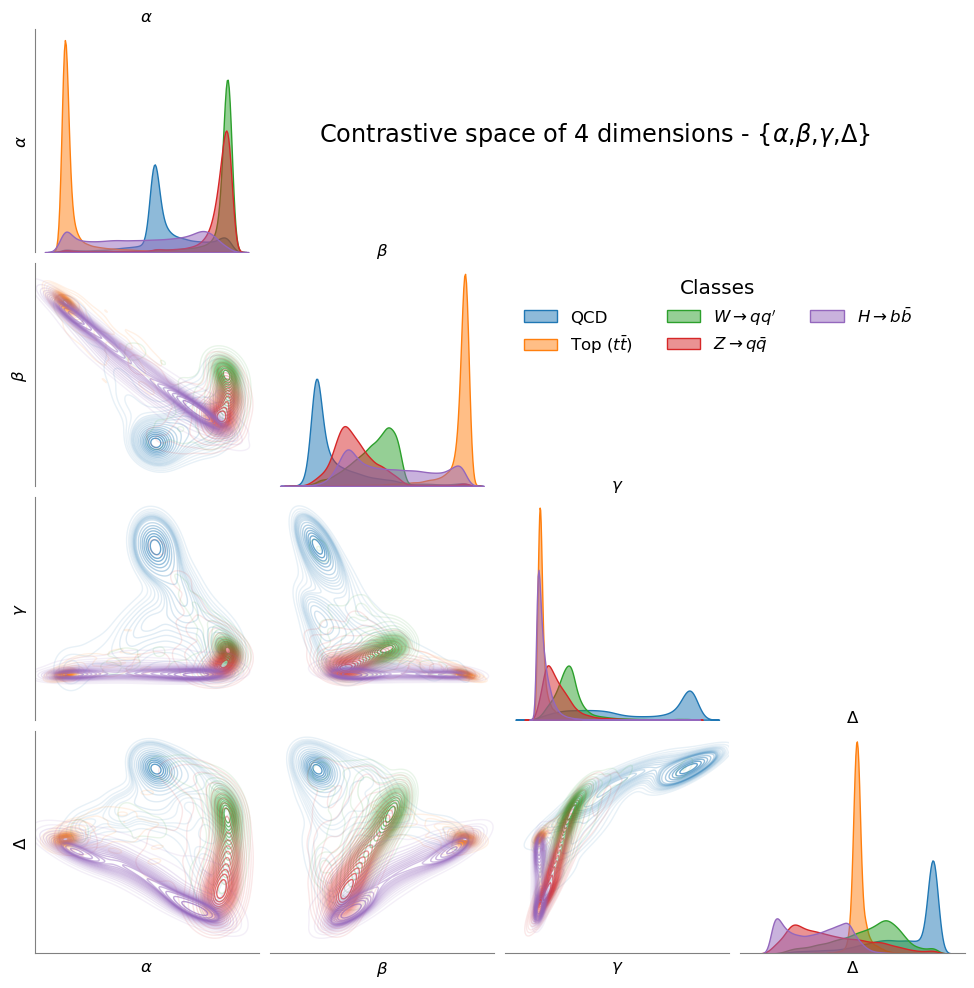

In [29]:
nplot = 100_000
x = np.concatenate([ref[:nplot],anom[:nplot]])
labels = np.concatenate([ref_labels[:nplot],anom_labels[:nplot]])
shuf = np.random.permutation(len(x))
x = x[shuf]
labels = labels[shuf]
label_names = {0:"QCD",1:r"Top ($t\bar{t}$)",2:r"$W \to qq^\prime$",3:r"$Z \to q\bar{q}$",4:r"$H \to b\bar{b}$"}
fig = make_corner2(x, labels, label_names=label_names, axwidth=3, return_fig=True, 
                kde=True, subsample=True, label_map=None)
fig.savefig("jetclass_space_100k.pdf")